In this notebook, we consider the results for the filtered OU process.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
import matplotlib.ticker as mticker
import numpy as np
import torch
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

In [2]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
tau_f = 0.01   # Correlation decay parameter
sigma = 1.0 # Standard deviation (amplitude) of the process

In [3]:
num_points_kappa = 50
kappa = torch.linspace(0.01, 0.99, num_points_kappa)

num_points_zeta = 50
zeta = torch.linspace(0.0, 2.0, num_points_zeta)

mean_rates = torch.zeros(num_points_kappa, num_points_zeta)
fano_factors = torch.zeros(num_points_kappa, num_points_zeta)

In [4]:
for i in range(num_points_kappa):
    for j in range(num_points_zeta):
        # u is given by zeta[j]*sigma, and tau_e depends on kappa[i]
        u = zeta[j] * sigma
        tau_e = tau_f / kappa[i]
        model = formula.GaussianUpCrossings(r_func=process.r_filtered_OU, u=u, tau=tau_e, kappa=kappa[i], sigma=sigma)
        mean_rates[i, j] = model.upcrossing_mean_rate()
        fano_factors[i, j] = model.upcrossing_fano_factor_CLT(epsilon_left=1e-2, epsilon_right=1e-5)

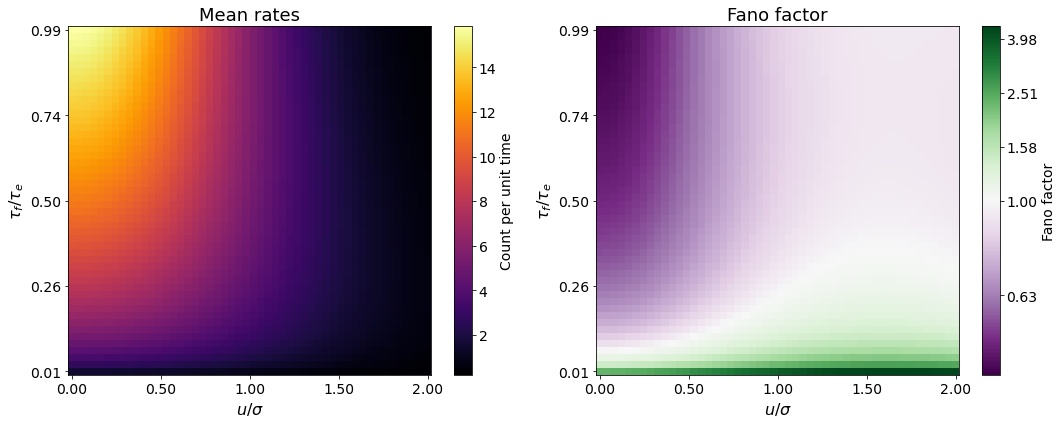

In [5]:
# Convert computed tensors to NumPy arrays for plotting
mean_rates_np = mean_rates.numpy()
fano_factors_np = fano_factors.numpy()
zeta_np = zeta.numpy()
kappa_np = kappa.numpy()

# -----------------------
# 3. Compute cell edges for arbitrary spacing
# -----------------------
def compute_edges(arr):
    """
    Given a 1D array (assumed sorted) representing cell centers,
    compute the cell edges so that each cell is centered on the given value.
    """
    edges = np.empty(len(arr) + 1)
    # Compute midpoints for interior edges
    edges[1:-1] = (arr[:-1] + arr[1:]) / 2.0
    # Extrapolate the first and last edges
    edges[0] = arr[0] - (arr[1] - arr[0]) / 2.0
    edges[-1] = arr[-1] + (arr[-1] - arr[-2]) / 2.0
    return edges

zeta_edges = compute_edges(zeta_np)
kappa_edges = compute_edges(kappa_np)

# -----------------------
# 4. Plotting using pcolormesh with the formal grid
# -----------------------
# Plotting parameters
cmap_mean = 'inferno'
cmap_fano = 'PRGn'
label_fontsize = 16
tick_fontsize = 14
title_fontsize = 18
cbar_labelsize = 14

# Define the number of ticks for the axes independently of the data spacing.
num_ticks = 5
x_ticks = np.linspace(zeta_np.min(), zeta_np.max(), num_ticks)
y_ticks = np.linspace(kappa_np.min(), kappa_np.max(), num_ticks)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left subplot: Mean Rates with Linear Scale ----
pc0 = axes[0].pcolormesh(zeta_edges, kappa_edges, mean_rates_np, shading='auto',
                         cmap=cmap_mean)
cbar0 = fig.colorbar(pc0, ax=axes[0])
cbar0.set_label("Count per unit time", fontsize=cbar_labelsize)
cbar0.ax.tick_params(labelsize=tick_fontsize)

axes[0].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[0].set_ylabel(r'$\tau_f/\tau_e$', fontsize=label_fontsize)
axes[0].set_title('Mean rates', fontsize=title_fontsize)
axes[0].set_xticks(x_ticks)
axes[0].set_yticks(y_ticks)
axes[0].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[0].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)

# ---- Right subplot: Fano Factors on a Log Scale with Divergence at 1 ----
# Transform the Fano factors to log10 space.
fano_log = np.log10(fano_factors_np)
# The diverging center corresponds to log10(1)=0.
norm_fano = TwoSlopeNorm(vmin=fano_log.min(), vcenter=0, vmax=fano_log.max())
pc1 = axes[1].pcolormesh(zeta_edges, kappa_edges, fano_log, shading='auto',
                         cmap=cmap_fano, norm=norm_fano)
cbar1 = fig.colorbar(pc1, ax=axes[1])
cbar1.set_label("Fano factor", fontsize=cbar_labelsize)
cbar1.ax.tick_params(labelsize=tick_fontsize)
# Adjust colorbar tick labels to show original Fano factor values.
def log_tick_formatter(x, pos):
    return f"{10**x:.2f}"
cbar1.formatter = mticker.FuncFormatter(log_tick_formatter)
cbar1.update_ticks()

axes[1].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[1].set_ylabel(r'$\tau_f/\tau_e$', fontsize=label_fontsize)
axes[1].set_title('Fano factor', fontsize=title_fontsize)
axes[1].set_xticks(x_ticks)
axes[1].set_yticks(y_ticks)
axes[1].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[1].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)

plt.tight_layout()
plt.show()

In [6]:
model = formula.GaussianUpCrossings(r_func=process.r_filtered_OU, u=0, tau=0.78, kappa=0.1, sigma=sigma)
print(model.upcrossing_fano_factor_CLT(epsilon_left=1e-2, epsilon_right=1e-5))

tensor(0.9300)


In [7]:
fano_log.shape

(50, 50)